# Model For Fraud Probability in Consumers

In this case, we use `c_transactions`, since this dataframe contains all the consumers who had a transaction, regardless of the merchants' information. Hence, the model can learn from more data.


In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV


In [2]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/08 21:55:52 WARN Utils: Your hostname, tray, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/10/08 21:55:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/08 21:55:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
# load c_transactions from 03_transactions_preprocess
df_transactions = spark.read.parquet("../data/curated/c_transactions")
df_transactions.show(5)

+-------+--------------+------------+------------------+--------------------+-----------+-----------------+--------------------+-----+--------+------+------------------+---------------------+
|user_id|order_datetime|merchant_abn|      dollar_value|            order_id|consumer_id|             name|             address|state|postcode|gender| fraud_probability|is_same_day_duplicate|
+-------+--------------+------------+------------------+--------------------+-----------+-----------------+--------------------+-----+--------+------+------------------+---------------------+
|     28|    2021-11-24| 29102388616|  68.4955798883829|af9bf760-56b0-4f8...|    1282374|Jamie Francis DVM|643 Michael Plain...|   WA|    6532|Female| 8.876031773353967|                false|
|     28|    2022-01-23| 29730124424| 4665.832659343163|5a584f62-df7d-464...|    1282374|Jamie Francis DVM|643 Michael Plain...|   WA|    6532|Female|16.068147454904413|                false|
|     29|    2021-11-25| 31334588839| 46

In [4]:
df_transactions.count()

14195505

We will try to label the consumers that have a NaN fraud probability.

In [5]:
# load df_transactions with merchants
# we use it to recover the order_id for each transaction 
# made by the user
transactions_all = spark.read.parquet("../data/curated/df_transactions")

# table to keep the order_id
order_lookup = (transactions_all
    .select("order_id", "user_id", "order_datetime")
    .dropDuplicates(["order_id"]))
order_lookup.write.parquet("../data/curated/order_lookup", mode="overwrite")
print(f"order_lookup stored: {order_lookup.count():,} rows")

order_lookup stored: 13,614,675 rows


In [6]:
# take unique values of consumer
consumer_txn_level = df_transactions.select(
    "user_id", "order_datetime", "merchant_abn", "fraud_probability",
    "state", "gender", "postcode", "dollar_value"
).dropDuplicates(["user_id", "order_datetime"])

# found the number of records that have fraud
n_total = consumer_txn_level.count()
n_null = consumer_txn_level.filter(F.col("fraud_probability").isNull()).count()
n_known = n_total - n_null

print(f"Total: {n_total}")
print(f"With fraud_probability: {n_known} ({n_known/n_total:.1%})")
print(f"NULL: {n_null} ({n_null/n_total:.1%})")

pdf_consumer = consumer_txn_level.toPandas()

Total: 8976957
With fraud_probability: 34765 (0.4%)
NULL: 8942192 (99.6%)


In this case, 99.6% of the records don't have a fraud probability.

In [7]:
# see fraud probability distribution, only use values that have a real fraud probability
labeled_consumer = pdf_consumer[pdf_consumer["fraud_probability"].notna()].copy()

print(labeled_consumer["fraud_probability"].describe(percentiles=[0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count    34765.000000
mean        14.945850
std          9.397401
min          8.287144
5%           8.516635
10%          8.767277
25%          9.630652
50%         11.718317
75%         16.153476
90%         24.156742
95%         33.521229
99%         57.585872
max         99.247380
Name: fraud_probability, dtype: float64


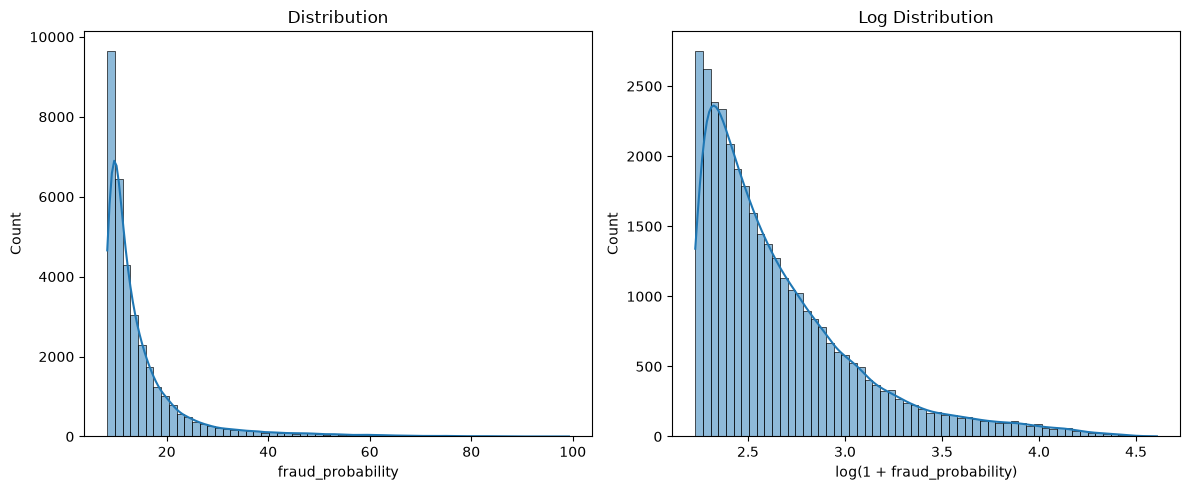

In [8]:
# visualise the distribution of fraud_probability
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(labeled_consumer["fraud_probability"], bins=60, kde=True)
plt.title("Distribution")
plt.xlabel("fraud_probability")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(labeled_consumer["fraud_probability"]), bins=60, kde=True)
plt.title("Log Distribution")
plt.xlabel("log(1 + fraud_probability)")

plt.tight_layout()
plt.show()

The distribution is skewed with values mostly concentrated between 9-11.

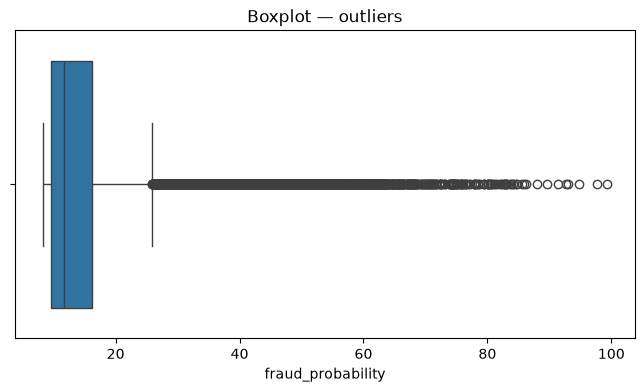

n = 34,765, k = 1.5
Log-scale Q1: 2.3637, Q3: 2.8422, IQR: 0.4785
Log-scale upper bound: 3.5599
Threshold (original): 34.16


In [ ]:
# Boxplot 
plt.figure(figsize=(8,4))
sns.boxplot(x=labeled_consumer["fraud_probability"])
plt.title("Boxplot — outliers")
plt.show()

labeled_consumer["log_fraud_probability"] = np.log1p(labeled_consumer["fraud_probability"])

q1 = labeled_consumer["log_fraud_probability"].quantile(0.25)
q3 = labeled_consumer["log_fraud_probability"].quantile(0.75)
iqr = q3 - q1

k = 1.5  
upper_bound_log = q3 + k * iqr
threshold_consumer = np.expm1(upper_bound_log) # take threshold using upper bound
print(f"n = {len(labeled_consumer):,}, k = {k}")
print(f"Log-scale Q1: {q1:.4f}, Q3: {q3:.4f}, IQR: {iqr:.4f}")
print(f"Log-scale upper bound: {upper_bound_log:.4f}")
print(f"Threshold (original): {threshold_consumer:.2f}")

In [10]:
# once having the threshold we apply it for the values that have a fraud probability
# anything above the threshold is flagges as fraud, rows with NaN stay like that
pdf_consumer["is_fraud"] = np.where(
    pdf_consumer["fraud_probability"].isna(),
    np.nan,
    (pdf_consumer["fraud_probability"] > threshold_consumer).astype(float)
)

print(pdf_consumer["is_fraud"].value_counts(dropna=False))
print(f"% fraud (labeled only): {pdf_consumer['is_fraud'].mean():.1%}")

is_fraud
NaN    8942192
0.0      33094
1.0       1671
Name: count, dtype: int64
% fraud (labeled only): 4.8%


# Train/test split

In [11]:
# separate the ones that have a label from the ones that don't
seed_set = pdf_consumer[pdf_consumer["is_fraud"].notna()].copy()
unlabeled = pdf_consumer[pdf_consumer["is_fraud"].isna()].copy()  # we're going to try to label these values

print(f"Seed set (with label): {len(seed_set):,}")
print(f"Unlabeled (predict): {len(unlabeled):,}")

# stratified split, using only the labeled transactions
train, test = train_test_split(
    seed_set, test_size=0.3, random_state=42, stratify=seed_set["is_fraud"]
)

print(f"Train set: {len(train):,} samples, {train['is_fraud'].mean():.1%} fraud")
print(f"Test set: {len(test):,} samples, {test['is_fraud'].mean():.1%} fraud")

Seed set (with label): 34,765
Unlabeled (predict): 8,942,192
Train set: 24,335 samples, 4.8% fraud
Test set: 10,430 samples, 4.8% fraud


# Feature Selection
To have a consistent model with the one done with the merchants, we will use Logistics Regression. However, depending on the results, we could test Random Forest as well, since this dataset is bigger.

**Feature Selection**
`dollar_value` is log-transformed, so its scale doesn't dominate the other features.

`state` and `gender` are categorical variables, so we use one-hot encoding.

We exclude `postcode`, like `category` for merchants, it has many distinct values relative to how many labelled rows we have per value, so the model wouldn't be able to generalise from it.

In [12]:
# log-transform dollar_value
pdf_consumer["log_dollar_value"] = np.log1p(pdf_consumer["dollar_value"])


# re-slice seed_set / unlabeled now that the log column exists
seed_set = pdf_consumer[pdf_consumer["is_fraud"].notna()].copy()
unlabeled = pdf_consumer[pdf_consumer["is_fraud"].isna()].copy()

# features for the model
num_cols = ["log_dollar_value"]
cat_cols = ["state", "gender"]
feature_cols = num_cols + cat_cols

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols), # standarise
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols), # one-hot encoder
])

# pipeline for model
model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

# Validating Model

We repeat the split 30 times with different seeds to see if the prediction AUC holds.

In [13]:
# repeat the model several times with different seeds
# observe if the AUC is the same accross all cases
n_repeats = 30
baseline_aucs = []

for seed in range(n_repeats):
    tr, te = train_test_split(seed_set, test_size=0.3, random_state=seed, stratify=seed_set["is_fraud"])
    m = clone(model)
    m.fit(tr[feature_cols], tr["is_fraud"])
    auc = roc_auc_score(te["is_fraud"], m.predict_proba(te[feature_cols])[:, 1])
    baseline_aucs.append(auc)

baseline_aucs = np.array(baseline_aucs)
print(f"Baseline AUC (30 splits): {baseline_aucs.mean():.3f} +/- {baseline_aucs.std():.3f}")

Baseline AUC (30 splits): 0.662 +/- 0.013


To compare results, we will also use Random Forest.

In [14]:
# preprocessing with Random Forest
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

model = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )),
])

In [15]:
# again check for the AUC with different seeds
n_repeats = 30
baseline_aucs = []

for seed in range(n_repeats):
    tr, te = train_test_split(seed_set, test_size=0.3, random_state=seed, stratify=seed_set["is_fraud"])
    m = clone(model)
    m.fit(tr[feature_cols], tr["is_fraud"])
    auc = roc_auc_score(te["is_fraud"], m.predict_proba(te[feature_cols])[:, 1])
    baseline_aucs.append(auc)

baseline_aucs = np.array(baseline_aucs)
print(f"Baseline AUC (30 splits): {baseline_aucs.mean():.3f} +/- {baseline_aucs.std():.3f}")

Baseline AUC (30 splits): 0.893 +/- 0.006


Accuracy:  0.898
Precision: 0.264
Recall:    0.635
F1-score:  0.373
AUC:       0.893

              precision    recall  f1-score   support

   not fraud       0.98      0.91      0.94      9929
       fraud       0.26      0.63      0.37       501

    accuracy                           0.90     10430
   macro avg       0.62      0.77      0.66     10430
weighted avg       0.95      0.90      0.92     10430



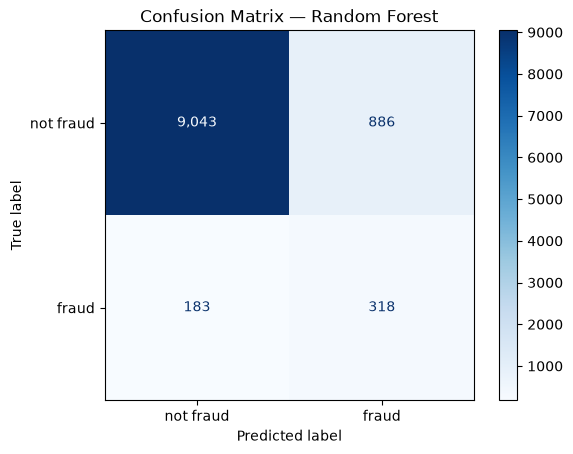

In [16]:
# see results from one model and see the classification metrics
tr, te = train_test_split(seed_set, test_size=0.3, random_state=42, stratify=seed_set["is_fraud"])

m = clone(model)
m.fit(tr[feature_cols], tr["is_fraud"])

y_true = te["is_fraud"]
y_pred = m.predict(te[feature_cols])
y_proba = m.predict_proba(te[feature_cols])[:, 1]

print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
print(f"Precision: {precision_score(y_true, y_pred):.3f}")
print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
print(f"F1-score:  {f1_score(y_true, y_pred):.3f}")
print(f"AUC:       {roc_auc_score(y_true, y_proba):.3f}")
print()
print(classification_report(y_true, y_pred, target_names=["not fraud", "fraud"]))

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["not fraud", "fraud"])
disp.plot(cmap="Blues", values_format=",d")
plt.title("Confusion Matrix — Random Forest")
plt.show()

The model performs well when it comes to predicting the non-fraud values. When the value is fraud, the model has low precision, meaning that some cases are flagged as fraud when they shouldn't be.

               feature  importance
0     log_dollar_value    0.987224
7            state_VIC    0.002648
8             state_WA    0.002092
9        gender_Female    0.002035
10         gender_Male    0.001703
2            state_NSW    0.001131
4            state_QLD    0.000947
11  gender_Undisclosed    0.000782
5             state_SA    0.000688
6            state_TAS    0.000344
3             state_NT    0.000292
1            state_ACT    0.000115


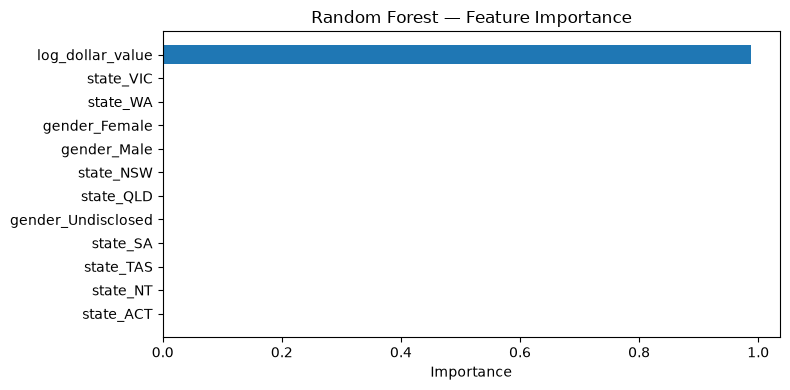

In [17]:
# see importance of features
# names of columns after one-hot encoding
ohe = m.named_steps["prep"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
all_feature_names = num_cols + cat_feature_names

importances = m.named_steps["clf"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_imp)

plt.figure(figsize=(8, 4))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest — Feature Importance")
plt.tight_layout()
plt.show()

The model is only considering the dollar value to determine if there's fraud or not; the rest of the features are irrelevant.

In [18]:
# see if the model is actually learning or if it's just learning dollar value
# split the test into dollar value quintiles and observe the AUC to determine
# if at one point the AUC decreases
te_check = te.copy()
te_check["proba"] = y_proba
te_check["dollar_value_band"] = pd.qcut(
    te_check["dollar_value"], 5,
    labels=["p0-20", "p20-40", "p40-60", "p60-80", "p80-100"],
    duplicates="drop"
)

print(f"AUC global: {roc_auc_score(te_check['is_fraud'], te_check['proba']):.3f}\n")

for band, group in te_check.groupby("dollar_value_band", observed=True):
    if group["is_fraud"].nunique() < 2:
        print(f"{band}: (n={len(group)}), can't calculate AUC")
        continue
    auc_band = roc_auc_score(group["is_fraud"], group["proba"])
    print(f"{band}: n={len(group):,}, fraud_rate={group['is_fraud'].mean():.1%}, AUC={auc_band:.3f}")

AUC global: 0.893

p0-20: n=2,086, fraud_rate=4.7%, AUC=0.490
p20-40: n=2,086, fraud_rate=4.5%, AUC=0.460
p40-60: n=2,086, fraud_rate=0.7%, AUC=0.847
p60-80: (n=2086), can't calculate AUC
p80-100: n=2,086, fraud_rate=14.1%, AUC=0.978


Below p40 AUC drops to 0.460.

In [19]:
# see how correlated is fraud_probability with log_dollar_value
corr_check = seed_set[["fraud_probability", "log_dollar_value"]].corr()
print(corr_check)

                   fraud_probability  log_dollar_value
fraud_probability           1.000000          0.139955
log_dollar_value            0.139955          1.000000


log_dollar_value has a positive correlation with fraud probability of 0.14. Therefore, this suggests that having a higher dollar value will increase the probability of fraud.

                     mean_dollar_value  fraud_rate     n
dollar_value_decile                                     
0                            13.127383    0.047167  3477
1                            42.221144    0.047468  3476
2                            96.792476    0.043716  3477
3                           282.322585    0.039701  3476
4                          1481.111623    0.013230  3477
5                          2368.358969    0.001151  3476
6                          2873.052072    0.000575  3476
7                          3594.783390    0.000575  3477
8                          4804.470753    0.001151  3476
9                         11366.326732    0.285879  3477


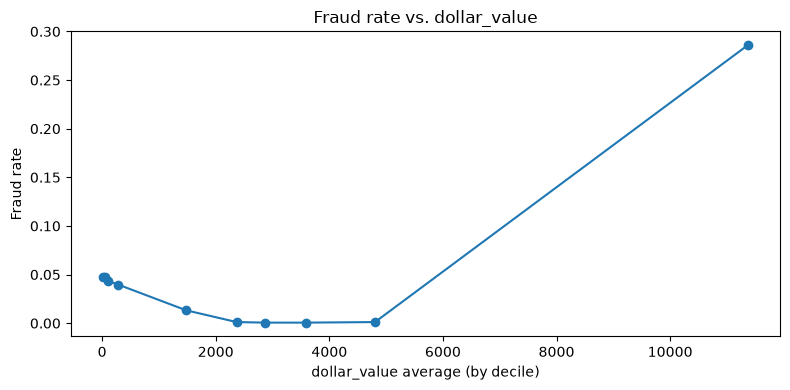

In [20]:
seed_set["dollar_value_decile"] = pd.qcut(seed_set["dollar_value"], 10, labels=False, duplicates="drop")

fraud_by_decile = seed_set.groupby("dollar_value_decile").agg(
    mean_dollar_value=("dollar_value", "mean"),
    fraud_rate=("is_fraud", "mean"),
    n=("is_fraud", "size")
)
print(fraud_by_decile)

plt.figure(figsize=(8, 4))
plt.plot(fraud_by_decile["mean_dollar_value"], fraud_by_decile["fraud_rate"], marker="o")
plt.xlabel("dollar_value average (by decile)")
plt.ylabel("Fraud rate")
plt.title("Fraud rate vs. dollar_value")
plt.tight_layout()
plt.show()

In [21]:
# see the point where the fraud rate increases
seed_set["dollar_value_pctile"] = pd.qcut(seed_set["dollar_value"], 20, labels=False, duplicates="drop")

fraud_by_pctile = seed_set.groupby("dollar_value_pctile").agg(
    mean_dollar_value=("dollar_value", "mean"),
    median_dollar_value=("dollar_value", "median"),
    fraud_rate=("is_fraud", "mean"),
    n_fraud=("is_fraud", "sum"),
    n=("is_fraud", "size")
)
print(fraud_by_pctile)

# look for outliers
print(seed_set["dollar_value"].describe(percentiles=[0.9, 0.95, 0.99, 0.999]))

                     mean_dollar_value  median_dollar_value  fraud_rate  \
dollar_value_pctile                                                       
0                             6.703104             6.777657    0.044278   
1                            19.555359            19.487728    0.050058   
2                            33.619760            33.328644    0.050633   
3                            50.822528            50.393831    0.044304   
4                            76.727192            76.687123    0.048879   
5                           116.869304           115.954627    0.038550   
6                           189.827146           184.152362    0.042578   
7                           374.818024           362.796548    0.036824   
8                          1030.583649           972.224538    0.023015   
9                          1931.380523          1952.055528    0.003450   
10                         2248.363934          2250.305015    0.001726   
11                       

The highest dollar_value_pctile has 992 detected values as fraud out of 1739 values. Therefore, this can't be considered an outlier; instead, these are cases where there is a greater probability of fraud.

In [22]:
# pseudo-labelling
# train the seed set, use that model for the unlabeled rows,
# by using the most confident predictions and retrain the model with the
# values added. See if the AUC improves.

max_add_per_round = 200         
pool_sample_size = 200_000       # only take a sample to test the model

results_before, results_after = [], []

for seed in range(n_repeats):
    # train the model
    tr, te = train_test_split(seed_set, test_size=0.3, random_state=seed, stratify=seed_set["is_fraud"])

    m0 = clone(model)
    m0.fit(tr[feature_cols], tr["is_fraud"])

    # predict the values
    pool = unlabeled.sample(n=min(pool_sample_size, len(unlabeled)), random_state=seed).copy()
    pool["pred_proba"] = m0.predict_proba(pool[feature_cols])[:, 1]

    low_threshold = np.percentile(pool["pred_proba"], 10)
    high_threshold = np.percentile(pool["pred_proba"], 90)

    auc_before = roc_auc_score(te["is_fraud"], m0.predict_proba(te[feature_cols])[:, 1])

    # use a threshold of the 10 most confident values
    conf_fraud = pool[pool["pred_proba"] >= high_threshold].nlargest(max_add_per_round, "pred_proba").assign(is_fraud=1.0)
    conf_clean = pool[pool["pred_proba"] <= low_threshold].nsmallest(max_add_per_round, "pred_proba").assign(is_fraud=0.0)
    new_labels = pd.concat([conf_fraud, conf_clean]).drop(columns=["pred_proba"])

    # retrain model with labels
    tr_aug = pd.concat([tr, new_labels], axis=0)
    m1 = clone(model)
    m1.fit(tr_aug[feature_cols], tr_aug["is_fraud"])
    auc_after = roc_auc_score(te["is_fraud"], m1.predict_proba(te[feature_cols])[:, 1])

    results_before.append(auc_before)
    results_after.append(auc_after)

results_before = np.array(results_before)
results_after = np.array(results_after)

print(f"Before pseudo-labels: {results_before.mean():.3f} +/- {results_before.std():.3f}")
print(f"After  pseudo-labels: {results_after.mean():.3f} +/- {results_after.std():.3f}")
print(f"Splits where it improved: {(results_after > results_before).mean():.1%}")

diff = results_after - results_before

print(f"Mean difference: {diff.mean():.4f}")
print(f"Std of difference: {diff.std():.4f}")
print(f"Splits worsened:  {(diff < 0).mean():.1%}")
print(f"Splits unchanged: {(diff == 0).mean():.1%}")

Before pseudo-labels: 0.893 +/- 0.006
After  pseudo-labels: 0.892 +/- 0.005
Splits where it improved: 23.3%
Mean difference: -0.0007
Std of difference: 0.0011
Splits worsened:  76.7%
Splits unchanged: 0.0%


In this case, we can see that using pseudo-labelling worsens the results rather than improving them. Therefore, we will only use one model.

In [23]:
# fit the model
model.fit(seed_set[feature_cols], seed_set["is_fraud"]) 

base_rate = seed_set["is_fraud"].mean()
# predict the unlabeled values
raw_pool_mean = model.predict_proba(unlabeled[feature_cols])[:, 1].mean()
print(f"Real fraud rate in seed set: {base_rate:.1%}")
print(f"Raw (uncalibrated) mean prediction on pool: {raw_pool_mean:.1%}")

Real fraud rate in seed set: 4.8%
Raw (uncalibrated) mean prediction on pool: 43.2%


In [24]:
# calibrate the model
calibrated_model = CalibratedClassifierCV(model, method="sigmoid", cv=5)
calibrated_model.fit(seed_set[feature_cols], seed_set["is_fraud"])

unlabeled["pred_proba"] = calibrated_model.predict_proba(unlabeled[feature_cols])[:, 1]
print(f"Calibrated mean prediction on pool: {unlabeled['pred_proba'].mean():.1%}")

Calibrated mean prediction on pool: 4.3%


In [25]:
# compare labeled numeric values with the whole dataset
# and see if the look similar
compare = pd.DataFrame({
    "labeled_mean": seed_set[num_cols].mean(),
    "labeled_median": seed_set[num_cols].median(),
    "population_mean": pdf_consumer[num_cols].mean(),
    "population_median": pdf_consumer[num_cols].median(),
})
print(compare)

print()
for col in num_cols:
    pct = (pdf_consumer[col] < seed_set[col].median()).mean()
    print(f"{col}: the labeled median sits at the {pct:.0%} percentile of the full population")

                  labeled_mean  labeled_median  population_mean  \
log_dollar_value      6.512912        7.658331         4.153881   

                  population_median  
log_dollar_value           4.146522  

log_dollar_value: the labeled median sits at the 99% percentile of the full population


In [26]:
# see the reliability of results
for q in [0.10, 0.20, 0.30, 0.40]:
    cutoff = seed_set["log_dollar_value"].quantile(q)
    raw_cutoff = np.expm1(cutoff)  # see cutoffs in dollars
    coverage = (unlabeled["log_dollar_value"] >= cutoff).mean()
    print(f"p{int(q*100)}: log_cutoff={cutoff:.2f}, dollar_cutoff=${raw_cutoff:,.0f}, sample coverage={coverage:.1%}")

p10: log_cutoff=3.31, dollar_cutoff=$26, sample coverage=74.6%
p20: log_cutoff=4.14, dollar_cutoff=$62, sample coverage=50.1%
p30: log_cutoff=4.98, dollar_cutoff=$144, sample coverage=25.8%
p40: log_cutoff=6.31, dollar_cutoff=$547, sample coverage=5.4%


In [27]:
# experiment: train a model where we only consider the relible results
# meaning that prices are higher than 571 (AUC 0.846-0.978).
# Compare with using all the values in dollar_value
seed_high = seed_set[seed_set["dollar_value"] >= 571].copy()

tr_high, te_high = train_test_split(
    seed_high, test_size=0.3, random_state=42, stratify=seed_high["is_fraud"]
)

# model
model_proba_high = calibrated_model.predict_proba(te_high[feature_cols])[:, 1]
auc_model_high = roc_auc_score(te_high["is_fraud"], model_proba_high)


auc_naive_high = roc_auc_score(te_high["is_fraud"], te_high["dollar_value"])

print(f"AUC calibrated (tier high): {auc_model_high:.3f}")
print(f"AUC dollar_value (tier high): {auc_naive_high:.3f}")

AUC calibrated (tier high): 0.990
AUC dollar_value (tier high): 0.942


In [28]:
# instead of a single well_supported cutoff, tag each row with a confidence tier
# previously, we saw that above p40, values for AUC were higher.
high_cutoff = np.expm1(seed_set["log_dollar_value"].quantile(0.40)) 

def confidence_tier(dollar_value):
    if dollar_value >= high_cutoff:      # p40 boundary, we get an AUC of 0.989
        return "high"
    else:                        # below $571 — AUC 0.46-0.49, no real signal
        return "unreliable"

unlabeled["confidence_tier"] = unlabeled["dollar_value"].apply(confidence_tier)
print(unlabeled["confidence_tier"].value_counts())

# predict for rows where the model actually has signal
# the unreliable rows will still be NaN
well_supported = unlabeled["confidence_tier"] == "high"
unlabeled_final = unlabeled[well_supported].copy()

confidence_tier
unreliable    8458119
high           484073
Name: count, dtype: int64


In [29]:
# used the unlabeled final and join with the whole dataset.
pdf_consumer = pdf_consumer.merge(
    unlabeled_final[["user_id", "order_datetime", "pred_proba"]],
    on=["user_id", "order_datetime"], how="left"
)

pdf_consumer["consumer_fraud_score_final"] = np.where(
    pdf_consumer["fraud_probability"].notna(),
    pdf_consumer["fraud_probability"] / 100,   # normalise
    pdf_consumer["pred_proba"]                 # use prediction of the model
)

n_final_known = pdf_consumer["consumer_fraud_score_final"].notna().sum()
print(f"Rows with a fraud score (real + pseudo-label): {n_final_known:,} / {len(pdf_consumer):,}")
print(f"NULL: {pdf_consumer['consumer_fraud_score_final'].isna().sum():,}")

pdf_consumer["consumer_fraud_score_final"].describe()

Rows with a fraud score (real + pseudo-label): 518,838 / 8,976,957
NULL: 8,458,119


count    518838.000000
mean          0.032203
std           0.058022
min           0.001918
25%           0.007996
50%           0.018721
75%           0.035064
max           0.992474
Name: consumer_fraud_score_final, dtype: float64

In [30]:
# rescale the threshold from before
threshold_consumer_normalized = threshold_consumer / 100 

# create the is_fraud_consumer variable
pdf_consumer["is_fraud_consumer"] = np.where(
    pdf_consumer["consumer_fraud_score_final"].isna(),
    np.nan,
    (pdf_consumer["consumer_fraud_score_final"] > threshold_consumer_normalized).astype(float)
)

print(pdf_consumer["is_fraud_consumer"].value_counts(dropna=False))

is_fraud_consumer
NaN    8458119
0.0     515162
1.0       3676
Name: count, dtype: int64


In [31]:
pdf_consumer = pdf_consumer[[
    "user_id", "order_datetime", "consumer_fraud_score_final", "is_fraud_consumer"
]].copy()

pdf_consumer.to_parquet("../data/curated/consumer_fraud_labels.parquet", index=False)
print(f"Stored: {len(pdf_consumer):,} rows")

Stored: 8,976,957 rows


In [32]:
# order lookup
order_lookup = spark.read.parquet("../data/curated/order_lookup").toPandas()

# merge to have order_id in the table
pdf_consumer_by_order = order_lookup.merge(
    pdf_consumer[["user_id", "order_datetime", "consumer_fraud_score_final", "is_fraud_consumer"]],
    on=["user_id", "order_datetime"], how="left"
)

print(f"Rows: {len(pdf_consumer_by_order):,} (before: {len(pdf_consumer):,})")

Rows: 13,614,675 (before: 8,976,957)


In [33]:
pdf_consumer_by_order[["order_id", "consumer_fraud_score_final", "is_fraud_consumer"]].to_parquet(
    "../data/curated/consumer_fraud_labels.parquet", index=False
)

# Important considerations
The trained model was only able to identify fraud cases when the dollar value was high; the performance of the model was unreliable. For this reason, we will still have 8491085 NaN values in the dataset, since it was not possible to determine with accuracy whether or not these consumers committed fraud during the transaction.